In [3]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 3.7 MB/s eta 0:00:28
   ---------------------------------------- 1.0/101.7 MB 2.4 MB/s eta 0:00:42
    --------------------------------------- 1.3/101.7 MB 2.2 MB/s eta 0:00:46
    --------------------------------------- 1.8/101.7 MB 2.2 MB/s eta 0:00:45
    --------------------------------------- 2.4/101.7 MB 2.4 MB/s eta 0:00:43
   - -------------------------------------- 2.9/101.7 MB 2.4 MB/s eta 0:00:42
   - -------------------------------------- 3.4/101.7 MB 2.4 MB/s eta 0:00:42
   - -------------------------------------- 3.9/101.7 MB 2.4 MB/s eta 0:00:42
   - -------------------------------------- 4.5/101.7 MB 2.4 MB/s eta 0:00:41
   - -------------------------------------- 4.7/101.7 MB 2.4 MB/s eta 0:00:41
   - ---


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

import xgboost as xgb

In [4]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [5]:
window_sizes = [5,10,20,30,40]

data_dir = Path("../data/processed/windows")

results = []

In [ ]:

for w in window_sizes:

    print(f"\nWindow size: {w}")

    data = np.load(data_dir / f"window_{w}.npz")

    X = data["X"]
    y = data["y"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    ## linear regression on window data
    lr = LinearRegression()
    lr.fit(X_train, y_train)

    pred = lr.predict(X_test)

    lr_rmse = rmse(y_test, pred)

    results.append({
        "window": w,
        "LinearRegression": lr_rmse
    })

    ## random forest on window data
    rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

    rf.fit(X_train, y_train)

    pred_rf = rf.predict(X_test)

    rf_rmse = rmse(y_test, pred_rf)

    results[-1]["RandomForest"] = rf_rmse


    ## xg boost on window data
    xgb_model = xgb.XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

    xgb_model.fit(X_train, y_train)

    pred_xgb = xgb_model.predict(X_test)

    xgb_rmse = rmse(y_test, pred_xgb)

    results[-1]["XGBoost"] = xgb_rmse



    


Window size: 5

Window size: 10

Window size: 20

Window size: 30

Window size: 40


In [10]:
results_df = pd.DataFrame(results)
# results_df = results_df[10:]

In [ ]:
# results_df = results_df[15:]

In [11]:
results_df

,window,LinearRegression,RandomForest,XGBoost
0,5,21.167449,17.888234,17.851815
1,10,20.506129,18.041817,17.759512
2,20,18.661582,17.997432,16.153557
3,30,17.413692,17.978110,14.965357
4,40,16.951347,17.485781,13.705896


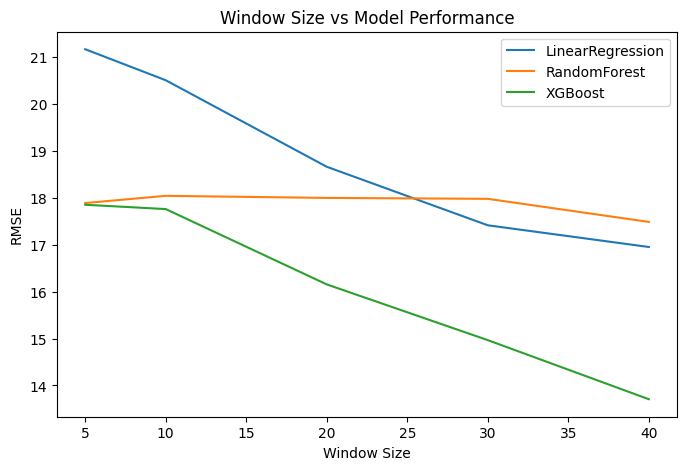

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.plot(results_df["window"], results_df["LinearRegression"], label="LinearRegression")
plt.plot(results_df["window"], results_df["RandomForest"], label="RandomForest")
plt.plot(results_df["window"], results_df["XGBoost"], label="XGBoost")

plt.xlabel("Window Size")
plt.ylabel("RMSE")
plt.title("Window Size vs Model Performance")

plt.legend()

plt.show()